<!-- colab-badge-top -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/07_lisa_pspline_psd.ipynb)

# Part 3C: LISA PSD estimation with P-splines

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**


## Goal and route

Estimate a smooth PSD with a cubic P-spline inside a Whittle likelihood and see how the roughness penalty changes the answer.

> **💡 Live route**
>
> Fit the simulated spectrum, inspect a whitened-power diagnostic, then change the smoothing strength in the question cell.


**Boundary:** The coefficient band uses a local Laplace approximation. A production Bayesian P-spline analysis must sample the full posterior and validate coverage, convergence, line treatment, and foreground identifiability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
from scipy.optimize import minimize

rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Why estimate the PSD inside the analysis?

A raw spectrum is jagged because every frequency bin contains a new random
noise draw. A P-spline builds a smooth curve from overlapping B-spline basis
functions, then penalises rapid changes between neighbouring coefficients.
The fit balances two requests:

- follow broad features supported by many nearby bins;
- do not chase every isolated periodogram spike.

The parameter $\lambda$ controls that balance. Small $\lambda$ gives a flexible
curve; large $\lambda$ gives a smoother curve.

For approximately independent complex Fourier coefficients $d_k$ with
one-sided PSD $S_k$, the Whittle negative log likelihood is, up to constants,

$$
-\log\mathcal L = \sum_k\left[\log S_k + \frac{I_k}{S_k}\right],
\qquad I_k=|d_k|^2.
$$

A raw periodogram is too variable to use as a smooth noise model.

There are many different models for PSDs. In this notebook we use *penalised*
splines. Write $\log S(f)=B(f)\beta$ in a cubic B-spline basis and penalise
second differences,

$$
-\log p(\beta\mid I)= -\log\mathcal L
+\frac{\lambda}{2}\lVert D_2\beta\rVert^2 + \mathrm{constant}.
$$

![A penalised spline built from weighted basis functions](https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/pspline_explainer.gif)

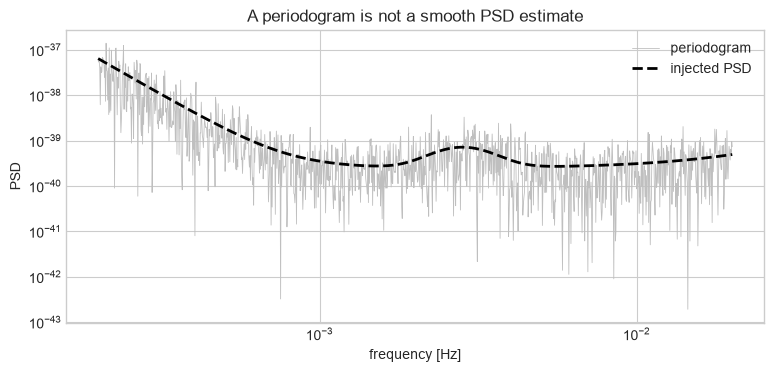

In [2]:
n_frequency = 1200
frequency = np.geomspace(2e-4, 2e-2, n_frequency)
log_frequency = np.log(frequency)

true_psd = 2.5e-40 * (1 + (8e-4 / frequency) ** 4 + 0.12 * (frequency / 7e-3) ** 2)
true_psd *= 1 + 1.8 * np.exp(-0.5 * ((np.log10(frequency) + 2.55) / 0.09) ** 2)
periodogram = true_psd * rng.exponential(size=n_frequency)

degree = 3
n_basis = 24
interior = np.linspace(log_frequency.min(), log_frequency.max(), n_basis - degree + 1)
knots = np.r_[[interior[0]] * degree, interior, [interior[-1]] * degree]
basis = np.column_stack(
    [
        BSpline(knots, np.eye(n_basis)[index], degree)(log_frequency)
        for index in range(n_basis)
    ]
)
second_difference = np.diff(np.eye(n_basis), n=2, axis=0)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.loglog(frequency, periodogram, color="0.75", lw=0.6, label="periodogram")
ax.loglog(frequency, true_psd, "k--", lw=2, label="injected PSD")
ax.set(
    xlabel="frequency [Hz]",
    ylabel="PSD",
    title="A periodogram is not a smooth PSD estimate",
)
ax.legend()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lisa-pspline-periodogram.png" alt="expected output: lisa-pspline-periodogram" style="max-width:100%">

</details>

## 2. Fit the penalised Whittle objective

The positive PSD constraint is automatic because the spline represents
`log(PSD)`. The smoothing strength `PENALTY` controls curvature, not an
arbitrary moving-window width.

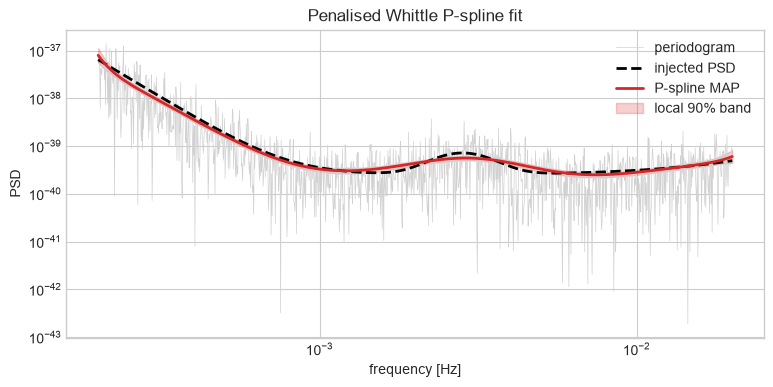

In [3]:
PENALTY = 80.0


def pspline_objective(coefficients, penalty=PENALTY):
    log_psd = basis @ coefficients
    roughness = second_difference @ coefficients
    return np.sum(log_psd + periodogram * np.exp(-log_psd)) + 0.5 * penalty * np.sum(
        roughness**2
    )


initial = np.linalg.lstsq(
    basis, np.log(np.maximum(periodogram, np.median(periodogram) * 1e-6)), rcond=None
)[0]
fit = minimize(pspline_objective, initial, method="L-BFGS-B")
if not fit.success:
    raise RuntimeError(fit.message)

log_psd_map = basis @ fit.x
psd_map = np.exp(log_psd_map)
curvature = periodogram * np.exp(-log_psd_map)
hessian = (
    basis.T @ (curvature[:, None] * basis)
    + PENALTY * second_difference.T @ second_difference
)
coefficient_covariance = np.linalg.pinv(hessian)
draws = rng.multivariate_normal(fit.x, coefficient_covariance, size=400)
psd_draws = np.exp(draws @ basis.T)
low, high = np.quantile(psd_draws, [0.05, 0.95], axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(frequency, periodogram, color="0.82", lw=0.5, label="periodogram")
ax.loglog(frequency, true_psd, "k--", lw=2, label="injected PSD")
ax.loglog(frequency, psd_map, color="C3", lw=2, label="P-spline MAP")
ax.fill_between(frequency, low, high, color="C3", alpha=0.22, label="local 90% band")
ax.set(xlabel="frequency [Hz]", ylabel="PSD", title="Penalised Whittle P-spline fit")
ax.legend()
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lisa-pspline-fit.png" alt="expected output: lisa-pspline-fit" style="max-width:100%">

</details>

## 3. Check the implied whitening

If the PSD model is adequate, `periodogram / psd_map` should fluctuate around
one without broad frequency-dependent structure. This is a numerical model
check, not proof that the physical noise components are identifiable.

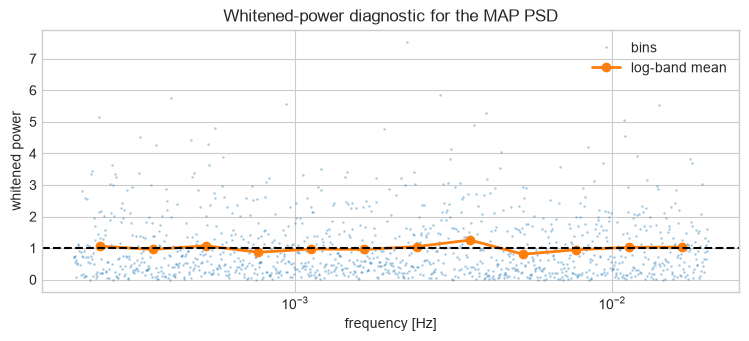

mean whitened power: 0.9999429888961079


In [4]:
whitened_power = periodogram / psd_map
log_bins = np.array_split(np.arange(n_frequency), 12)
bin_frequency = np.array([np.exp(np.mean(log_frequency[index])) for index in log_bins])
bin_power = np.array([np.mean(whitened_power[index]) for index in log_bins])

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.semilogx(frequency, whitened_power, ".", ms=2, alpha=0.25, label="bins")
ax.semilogx(bin_frequency, bin_power, "o-", lw=2, label="log-band mean")
ax.axhline(1, color="k", ls="--")
ax.set(
    xlabel="frequency [Hz]",
    ylabel="whitened power",
    title="Whitened-power diagnostic for the MAP PSD",
)
ax.legend()
plt.show()
print("mean whitened power:", whitened_power.mean())

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lisa-pspline-whitening.png" alt="expected output: lisa-pspline-whitening" style="max-width:100%">

</details>

### Question

Refit with penalties 2, 80, and 5000. Which fit follows periodogram spikes, and which erases the broad bump near 3 mHz?

In [5]:
penalties = [2.0, 80.0, 5000.0]
fits_by_penalty = {}
# Your code here: fit each penalty, then plot the three estimates together with
# the injected PSD on the same log-log axes.

<details>
<summary>Hint</summary>

Pass the penalty explicitly and warm-start each fit from `fit.x`. Plot the resulting PSDs against the injected PSD.

</details>


## Instrument noise and foregrounds

One observed total spectrum does not identify two unrestricted positive smooth
surfaces. Separating an instrumental PSD from Galactic confusion requires
additional structure: response-informed shapes, multiple TDI channels,
time dependence, informative regularisation, resolved-source information, or
other data. A visually good total-PSD fit alone is not component recovery.

<!-- colab-badge-next -->
Next: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/08_lisa_wdm_time_frequency.ipynb)

---

# Worked solutions

Everything above this line is the lab notebook, unchanged. Below are the
solutions to its exercises, as cells that actually run: execute the notebook
from the top and every variable they need will already exist.

## Question: what does the penalty control?

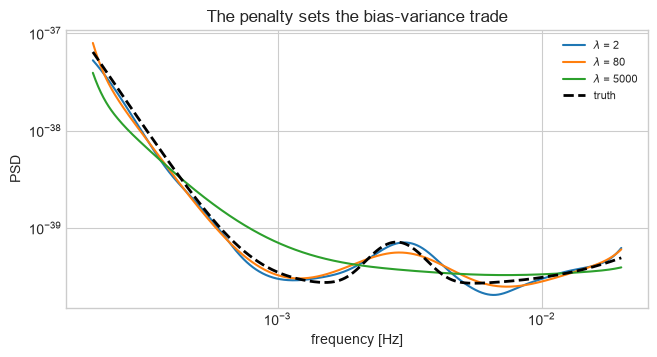

In [6]:
for penalty in penalties:
    result = minimize(
        lambda beta: pspline_objective(beta, penalty), fit.x, method="L-BFGS-B"
    )
    fits_by_penalty[penalty] = np.exp(basis @ result.x)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for penalty, estimate in fits_by_penalty.items():
    ax.loglog(frequency, estimate, label=f"$\\lambda$ = {penalty:g}")
ax.loglog(frequency, true_psd, "k--", lw=2, label="truth")
ax.set(xlabel="frequency [Hz]", ylabel="PSD", title="The penalty sets the bias-variance trade")
ax.legend(fontsize=8)
plt.show()

$\lambda=2$ is too weak: the fit chases individual periodogram spikes, which are
noise, not structure. $\lambda=5000$ is too strong: it irons the broad 3 mHz
bump flat, which *is* structure. The middle value is roughly right, and the fact
that "roughly right" has to be chosen is the whole difficulty — in a real
analysis there is no truth curve to check against, so $\lambda$ is either
marginalised over or set by cross-validation.